# Phase-2b Lyα P1D emulator — Notebook 2: performance walkthrough

This notebook loads the **finalized LOSO checkpoints** and renders the key
performance figures **inline**, reusing the figure logic from the keeper
diagnostic `scripts/plot_performance_walkthrough.py` (imported, not copied) so
the notebook and the production walkthrough can never disagree.

All figures are evaluated on **held-out** sims (LOSO). It is **robust to missing
checkpoints**: if `checkpoints/final_fold{0..7}` are absent it falls back to
`walkthrough_fold0` (or any single fold) and prints a clear message rather than
crashing.

**Companion:** `01_emulator_training.ipynb` shows how these checkpoints are trained.

In [1]:
# The `emu-jax` kernelspec sets CPU-only JAX + PYTHONNOUSERSITE.
import os, sys
from pathlib import Path
# Portable repo-root detection (see 01_emulator_training.ipynb).
ROOT = Path(os.environ.get('HCD_PRIYA_ROOT', '')).expanduser()
if not (ROOT / 'hcd_analysis').is_dir():
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'hcd_analysis').is_dir()), Path.cwd())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json, warnings
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

import hcd_analysis.emulator  # noqa: F401  (enables x64)
from hcd_analysis.emulator.data import (
    load_cache, make_splits, reconstruct_P_filt, COARSE_NAMES, DATA_RANGE,
)
from hcd_analysis.emulator import train as T
# reuse the keeper walkthrough's figure functions directly
import scripts.plot_performance_walkthrough as W

print('jax devices:', jax.devices())
CACHE = W.CACHE
N_FOLDS = W.N_FOLDS
PARAM_NAMES = W.PARAM_NAMES

jax devices: [CpuDevice(id=0)]


## 1. Load the cache + the finalized checkpoints (robust)

We load whichever finalized folds are on disk. If none of `final_fold{0..7}`
exist we fall back to `walkthrough_fold0`. The single-fold figures use fold 0
(or the fallback); the multi-fold figures (B5 Fisher spread, Head A) use
whatever folds loaded.

In [2]:
d = load_cache(CACHE)
kf = d['kfkms'][0]
z_levels = np.unique(np.round(d['z_grid'], 1))
print(f"cache: {d['P_tier_p'].shape[0]} rows, n_k={len(kf)}, "
      f'z-levels={len(z_levels)}')

CKPT = str(W.ROOT / 'checkpoints/final_fold{f}')

def _exists(stem):
    return Path(stem + '.eqx').exists() and Path(stem + '.meta.json').exists()

models, norms, splits = {}, {}, {}
avail = [f for f in range(N_FOLDS) if _exists(CKPT.format(f=f))]
if avail:
    for f in avail:
        m, meta, nrm = T.load_checkpoint(CKPT.format(f=f))
        models[f], norms[f] = m, nrm
        splits[f] = make_splits(d, f, n_folds=N_FOLDS, holdout_frac=0.15)
    print(f'loaded finalized folds: {avail}')
else:
    fb = str(W.ROOT / 'checkpoints/walkthrough_fold0')
    if _exists(fb):
        m, meta, nrm = T.load_checkpoint(fb)
        models[0], norms[0] = m, nrm
        splits[0] = make_splits(d, 0, n_folds=N_FOLDS, holdout_frac=0.15)
        avail = [0]
        print('FALLBACK: final_fold* missing; using checkpoints/walkthrough_fold0 as fold 0')
    else:
        raise FileNotFoundError(
            'No finalized or walkthrough checkpoints found. '
            'Run scripts/run_loso_sweep.py first (see NB 1).')

# the walkthrough figure fns reference a single (model,norm,split); fold 0 here.
F0 = avail[0]
m0, n0, s0 = {0: models[F0]}, {0: norms[F0]}, {0: splits[F0]}
n_loaded = len(avail)
print(f'{n_loaded} fold(s) available for the multi-fold figures')

cache: 21440 rows, n_k=172, z-levels=18


loaded finalized folds: [0, 1, 2, 3, 4, 5, 6, 7]
8 fold(s) available for the multi-fold figures


## HEAD B — P1D / cosmology

### B1 — Predicted vs true per-class P1D (+ fractional residual)

**What:** deployed `P̂` vs truth for the 3 best-sampled held-out rows per class,
log-log, with the fractional residual underneath. **How to read:** dashed (pred)
should overlay solid (true); the residual subpanel should sit near 0 (±). The
grey band is below the DESI `k_min`; the right-edge turnover is the per-row
Nyquist. **Good:** tight overlay, residual within a few %. **Bad:** systematic
tilt or offset in the residual.

B1 pred/true frac-resid RMS per class: {'clean': 0.0128, 'LLS': 0.0038, 'subDLA': 0.0155, 'DLA': 0.0222}


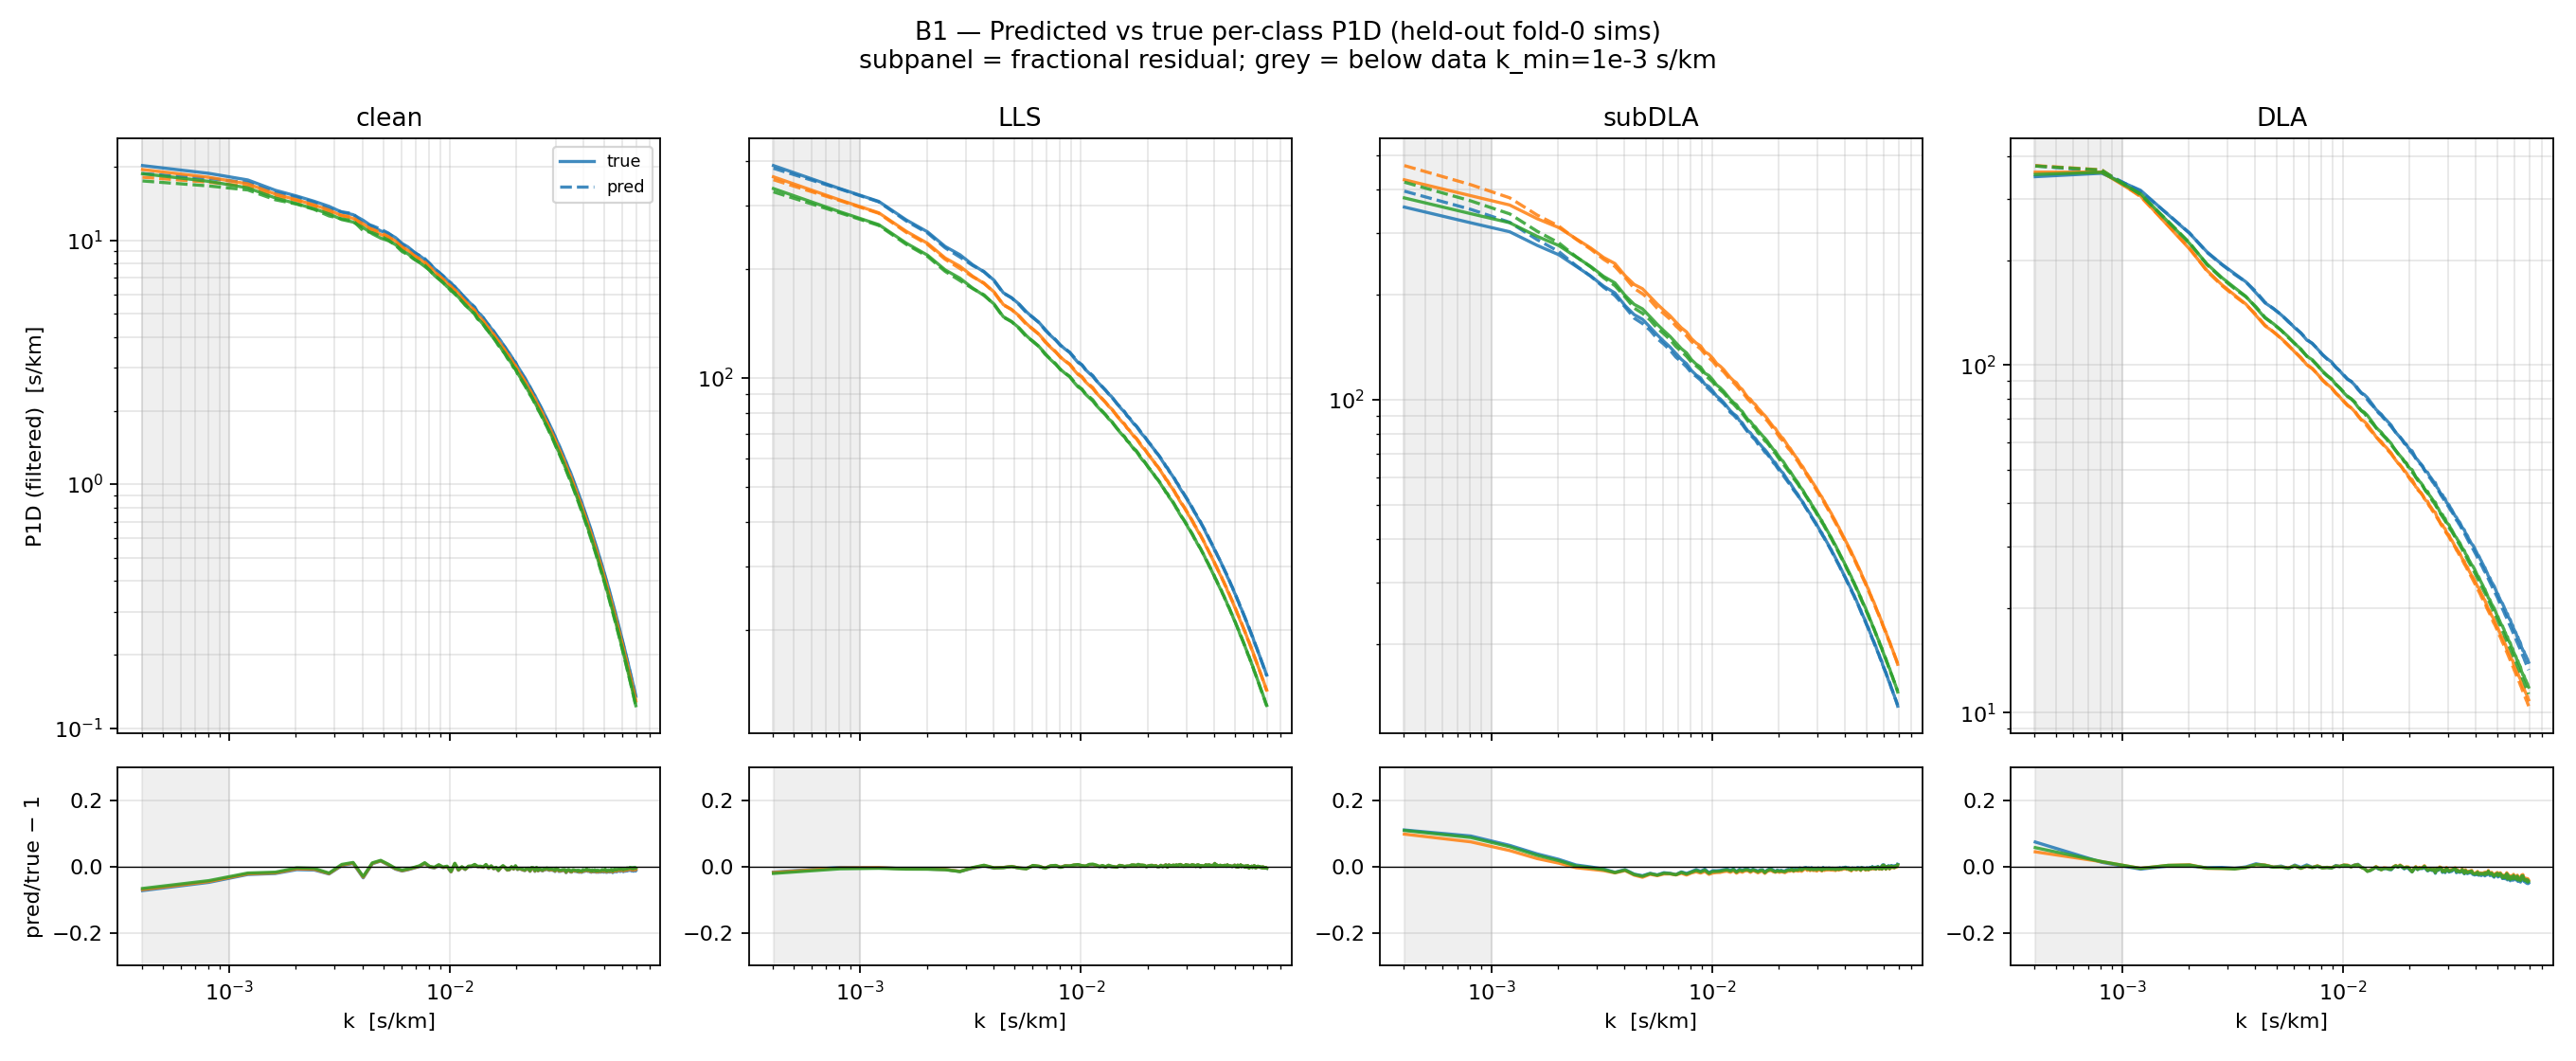

In [3]:
p, fr = W.figB1_pred_vs_true_p1d(m0, n0, s0, d, kf)
print('B1 pred/true frac-resid RMS per class:',
      {k: round(v, 4) for k, v in fr.items()})
from IPython.display import Image, display
display(Image(filename=str(p)))

### B2 — Deployed fractional P1D error vs k (in-range, all folds) + CV floor

**What:** median `|P̂/P − 1|` vs k per class (IQR shaded), over **all** loaded
folds' held-out rows, restricted to the data range; dashed black = the
cosmic-variance (CV) floor — the irreducible sampling scatter. **How to read:**
the error should approach (not beat) the CV floor; clean is tightest, HCD
classes are noisier (fewer absorbers). **Good:** error near the CV floor across
k. **Bad:** error rising well above the floor, especially a coherent low-k rise.

/home/mfho/.conda/envs/emu-jax/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/mfho/.conda/envs/emu-jax/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


B2 deployed frac-err RMS per class (in-range): {'clean': 0.0114, 'LLS': 0.0116, 'subDLA': 0.0133, 'DLA': 0.0246}


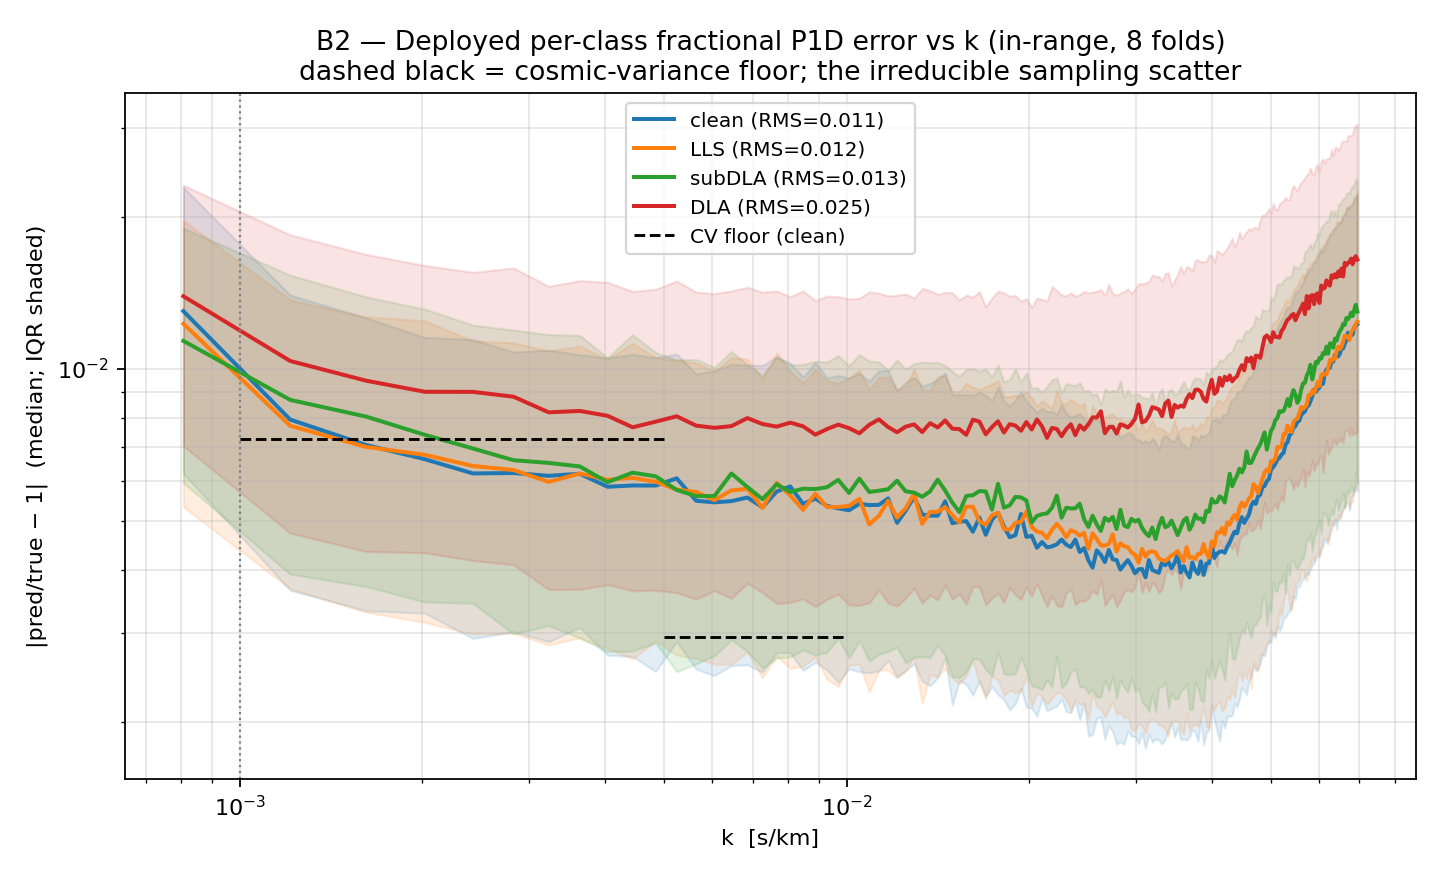

In [4]:
cv_floor = W.load_cv_floor()
frac, kf2 = W._deployed_frac_in_range(models, norms, splits, d)
p, rms = W.figB2_deployed_frac_err_vs_k(frac, kf2, cv_floor)
print('B2 deployed frac-err RMS per class (in-range):',
      {k: round(v, 4) for k, v in rms.items()})
display(Image(filename=str(p)))

### B3 — Learned cosmology response ∂lnP/∂θ vs k (jacfwd)

**What:** `σ_cosmo·∂r̂/∂θ` (= `∂lnP̂/∂θ`) vs k for all 9 params, by class, via
`jax.jacfwd` at a fiducial held-out point. **How to read:** larger |response| =
the P1D constrains that param more; sign-flips across k = shape/tilt sensitivity.
**Good:** A_p shows a coherent low-k amplitude response, n_s a tilt; IGM params
respond where physically expected. **Bad:** a param with ~zero response
everywhere is unconstrained by the P1D alone.

B3 response amplitude |∂lnP/∂θ|_rms per param: {'ns': 0.181, 'Ap': 0.11, 'herei': 0.006, 'heref': 0.007, 'alphaq': 0.011, 'hub': 0.188, 'omegamh2': 0.039, 'hireionz': 0.043, 'bhfeedback': 0.008}


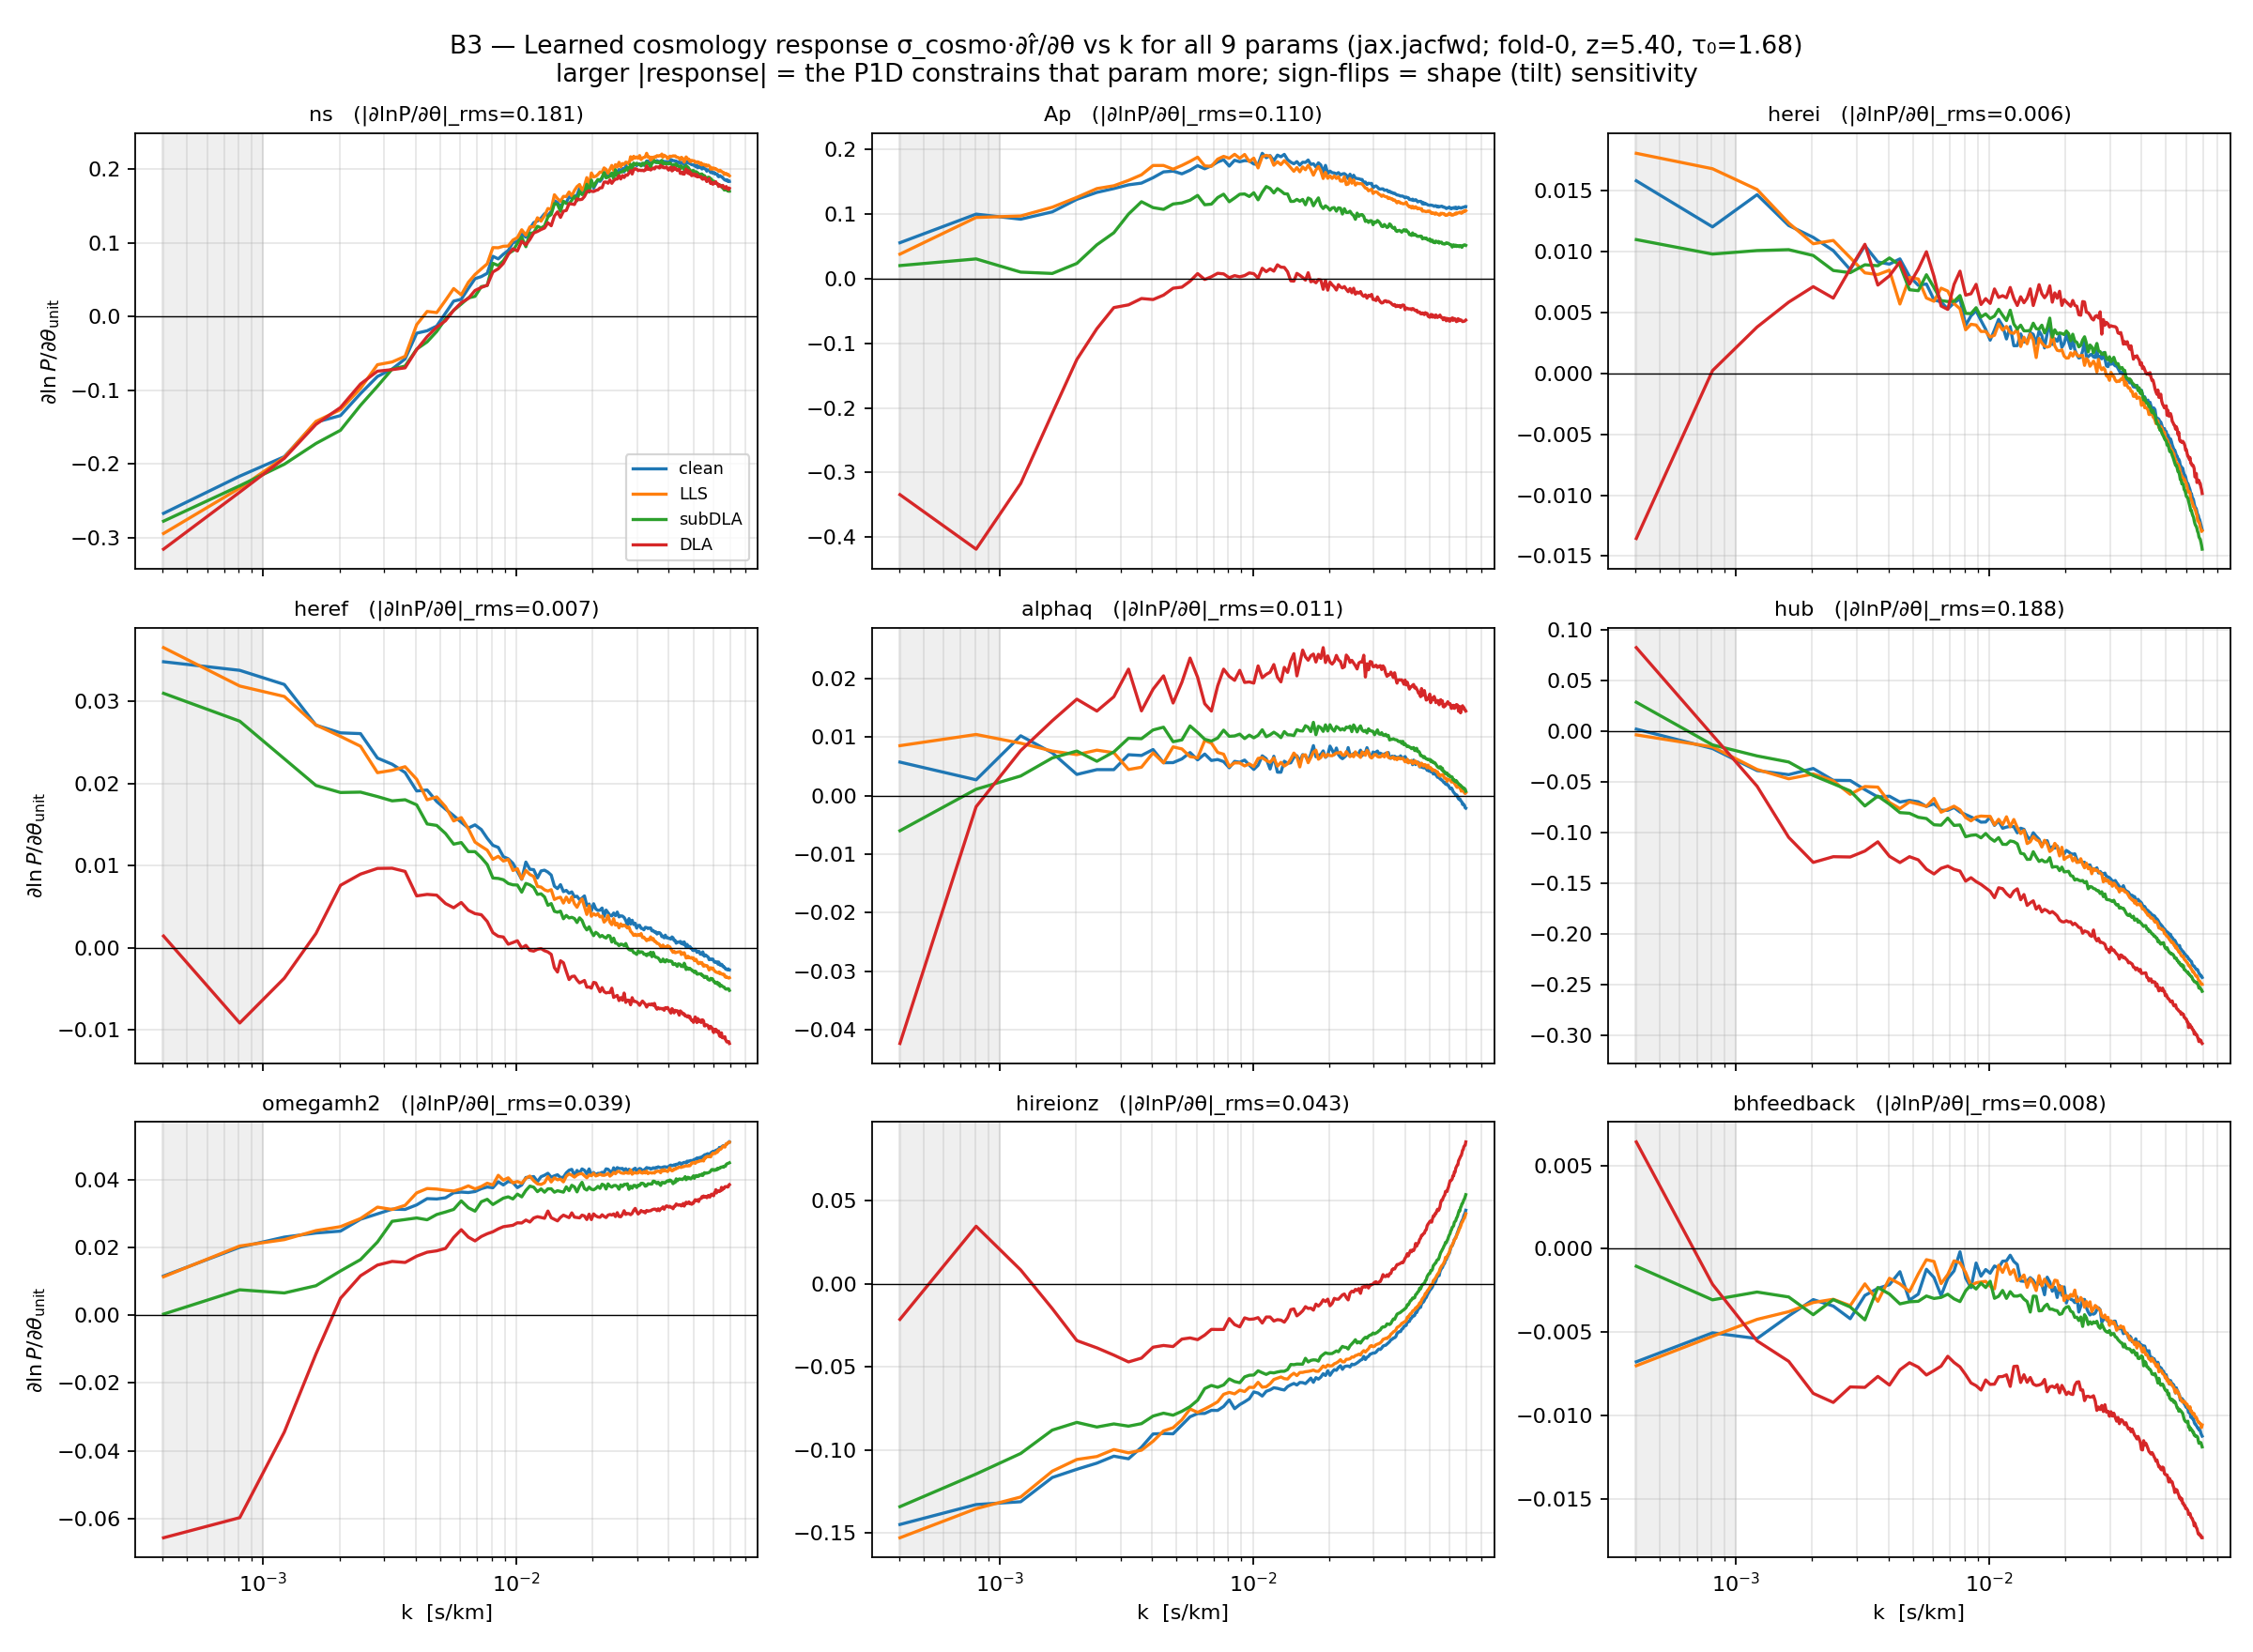

In [5]:
p, constr = W.figB3_cosmology_response(m0, n0, s0, d, kf)
print('B3 response amplitude |∂lnP/∂θ|_rms per param:',
      {k: round(v, 3) for k, v in constr.items()})
display(Image(filename=str(p)))

### B4 — Within-cell θ-tracking + honest (a)/(b) error decomposition

**What:** *left* — true vs predicted log-P1D deviation from the deployed
baseline `m̂` (the cosmology signal), pooled over classes; *right* — the
whitened error split into **(a)** residual-head fit error and **(b)** baseline
mis-fit (σ_cosmo-amplified), per class. **How to read:** left hexbin should hug
the `y=x` line with corr→1 and spread-ratio→1; right bars should be a small
fraction of `σ_signal`. **Good:** high corr, small (a)+(b). **Bad:** corr well
below 1, or a large (b) (baseline drifted off its cell-mean floor).

B4 honest θ-tracking corr = 0.980, spread-ratio = 1.018


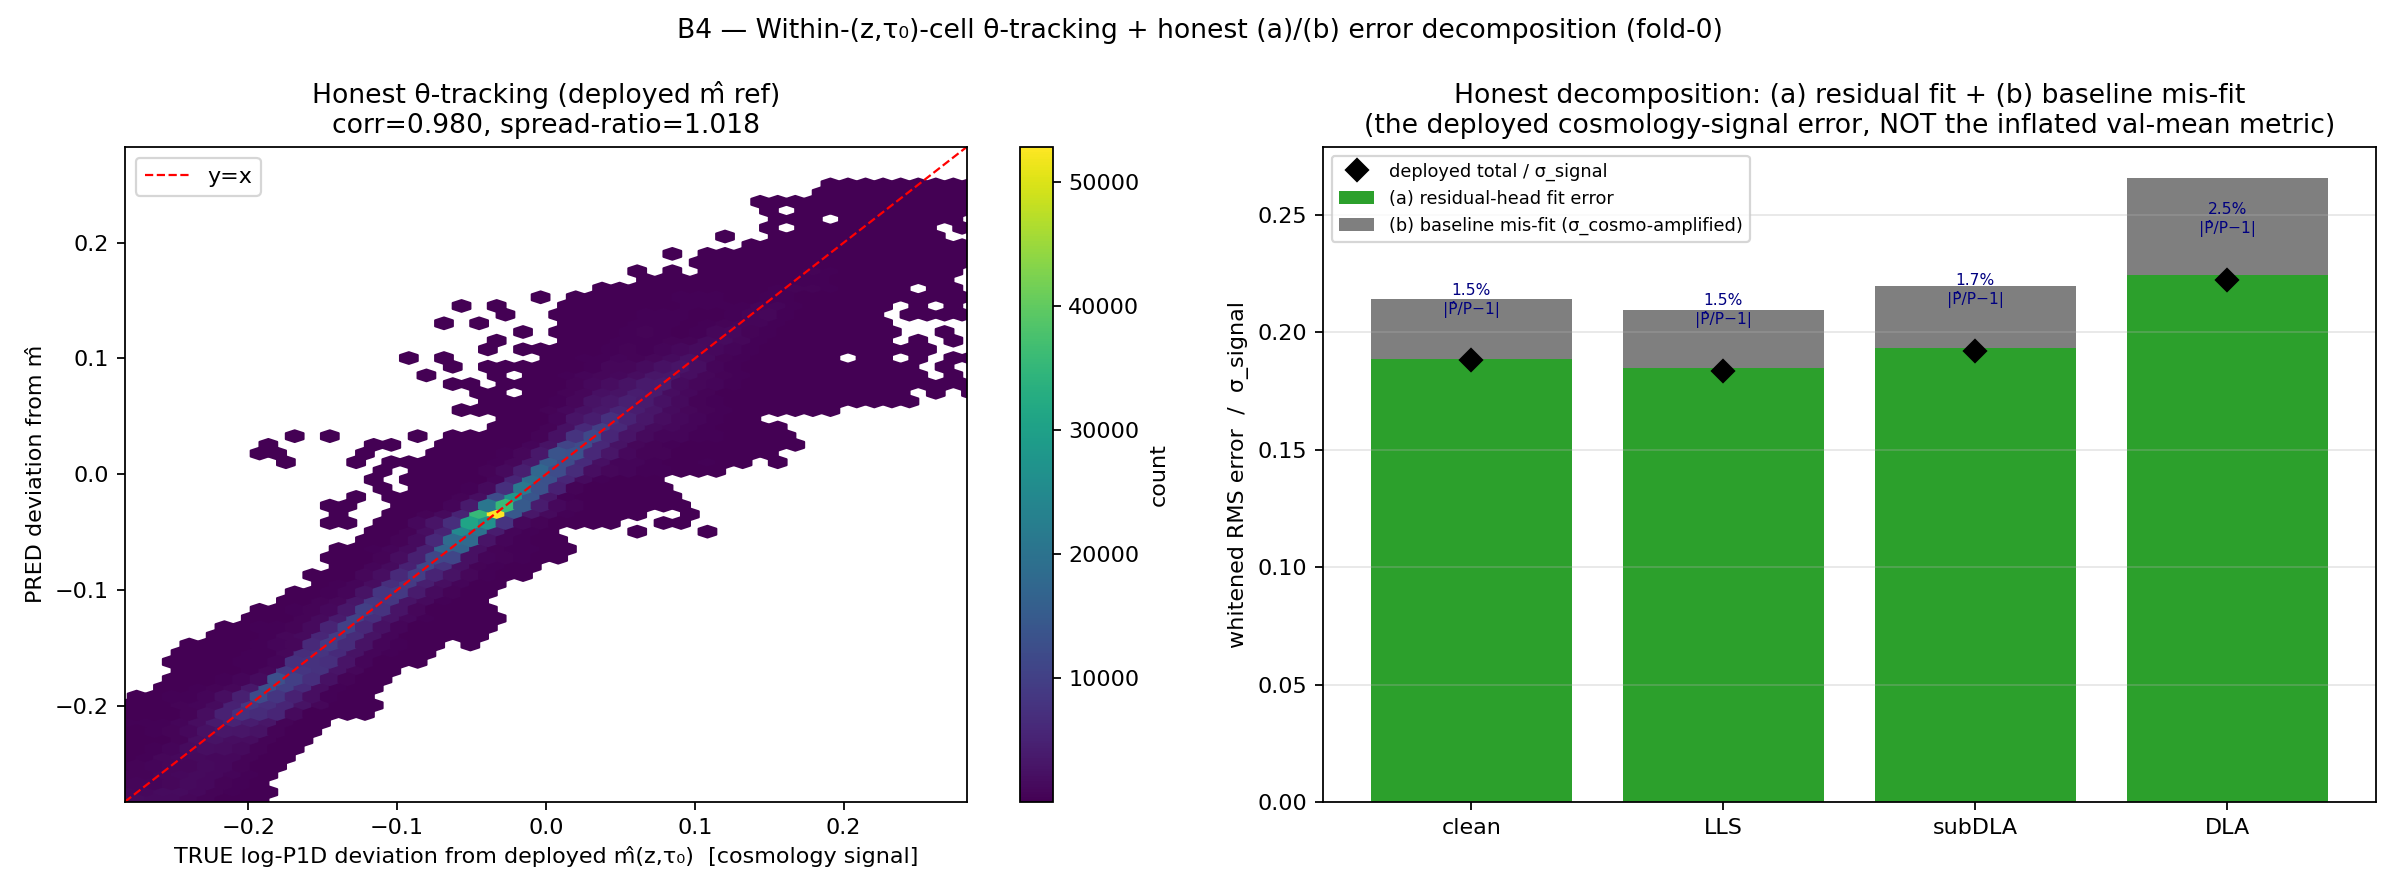

In [6]:
p, tt = W.figB4_theta_tracking(m0, n0, s0, d)
print(f"B4 honest θ-tracking corr = {tt['honest_corr']:.3f}, "
      f"spread-ratio = {tt['spread_ratio']:.3f}")
display(Image(filename=str(p)))

### B5 — Per-fold A_p & n_s Fisher-bias spread

**What:** the deployed in-range Fisher-bias of A_p and n_s for each loaded LOSO
fold (DESI-DR1-like diagonal covariance, z=3). **How to read:** every bar should
sit inside the ±0.2σ green gate; the dotted line is the RMS-over-folds. **Good:**
all folds in the gate, small RMS. **Bad:** a fold spiking past the gate (a
cosmology the model extrapolates poorly to).

> With a single fold loaded this shows just that fold (the spread needs all 8).

B5 A_p RMS = 0.067σ (max |0.131|);  n_s RMS = 0.071σ (max |0.131|)


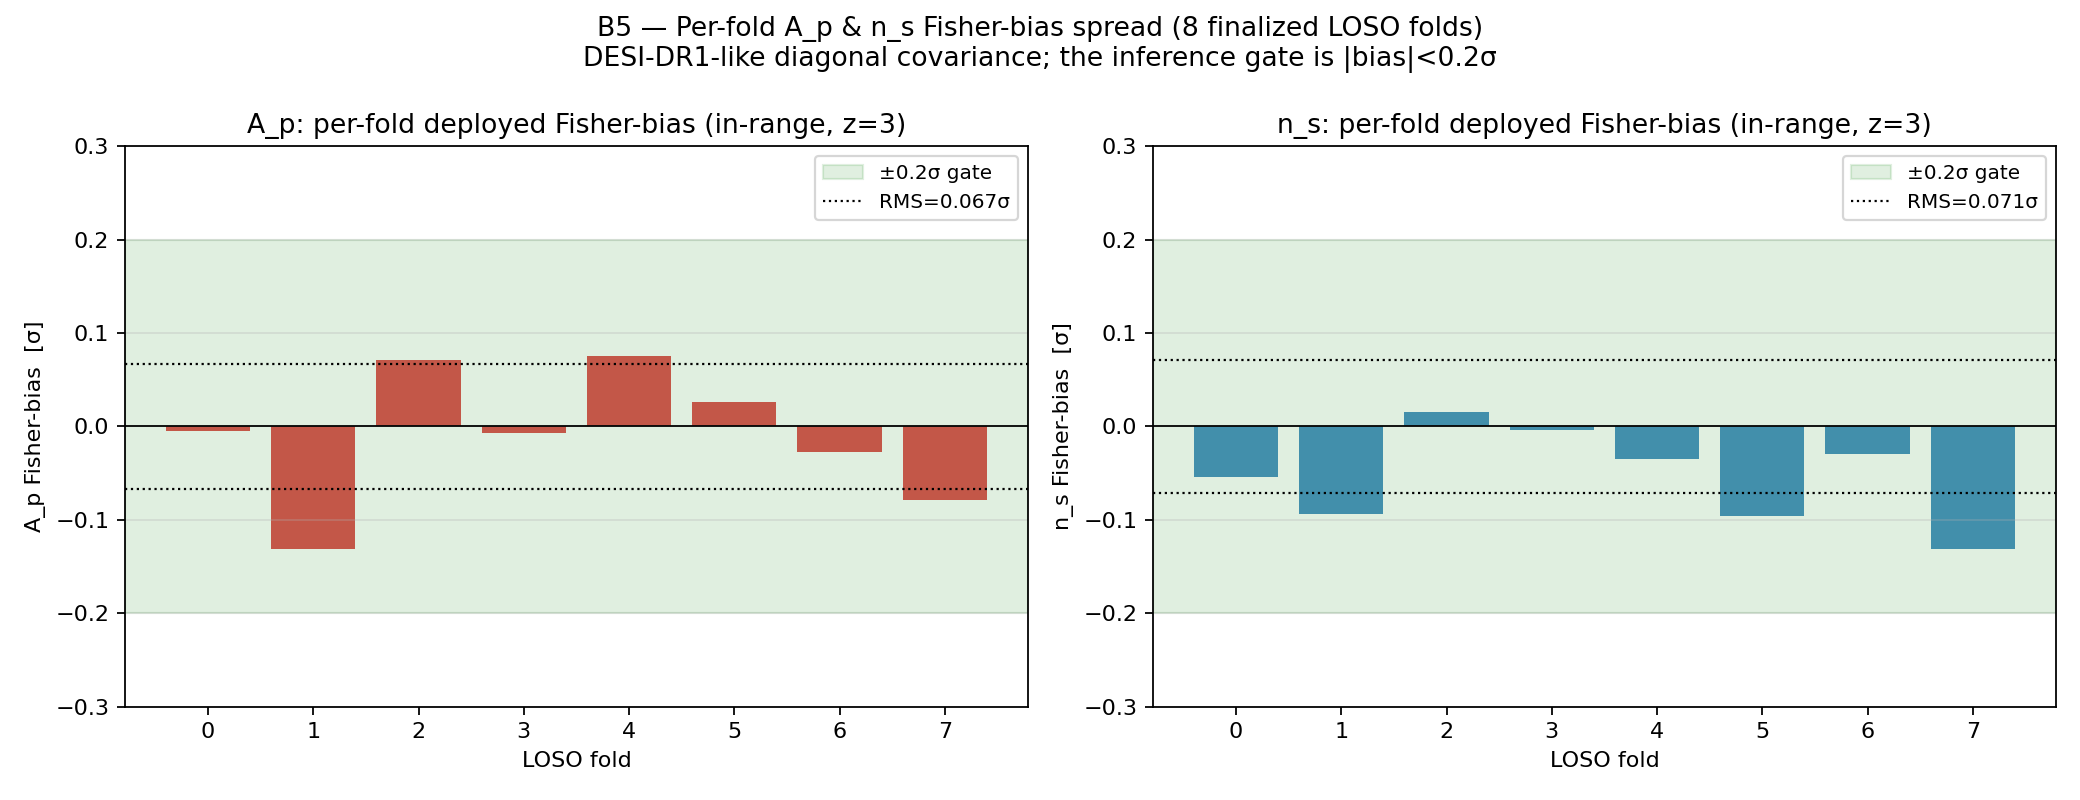

In [7]:
p, fb = W.figB5_fisher_bias_perfold(models, norms, splits, d)
print(f"B5 A_p RMS = {fb['Ap_rms_sigma']:.3f}σ (max |{fb['Ap_max_abs']:.3f}|);  "
      f"n_s RMS = {fb['ns_rms_sigma']:.3f}σ (max |{fb['ns_max_abs']:.3f}|)")
display(Image(filename=str(p)))

### B6 — Multi-fidelity high-k: MF vs LF-extrapolated vs HF-standalone

**What:** RMS fractional P1D error vs k in the KODIAQ high-k band for the
validated ρ(k,z)-only MF model, the LF-extrapolated-alone backbone, and an
HF-standalone fit, aggregated over HF-LOSO folds. **How to read:** above the LF
Nyquist (dash-dot ~0.069 s/km) the LF extrapolation degrades; the MF (blue)
should track best across the shaded KODIAQ band. **Good:** MF below both
alternatives at high k. Needs the HR cache + res_corr table; degrades gracefully
if absent.

B6 KODIAQ-band RMS frac err per class:
  clean   MF=0.182  LF-extrap=0.767  HF-standalone=0.666
  LLS     MF=0.183  LF-extrap=0.772  HF-standalone=0.822
  subDLA  MF=0.188  LF-extrap=0.759  HF-standalone=0.592
  DLA     MF=0.182  LF-extrap=0.722  HF-standalone=0.606


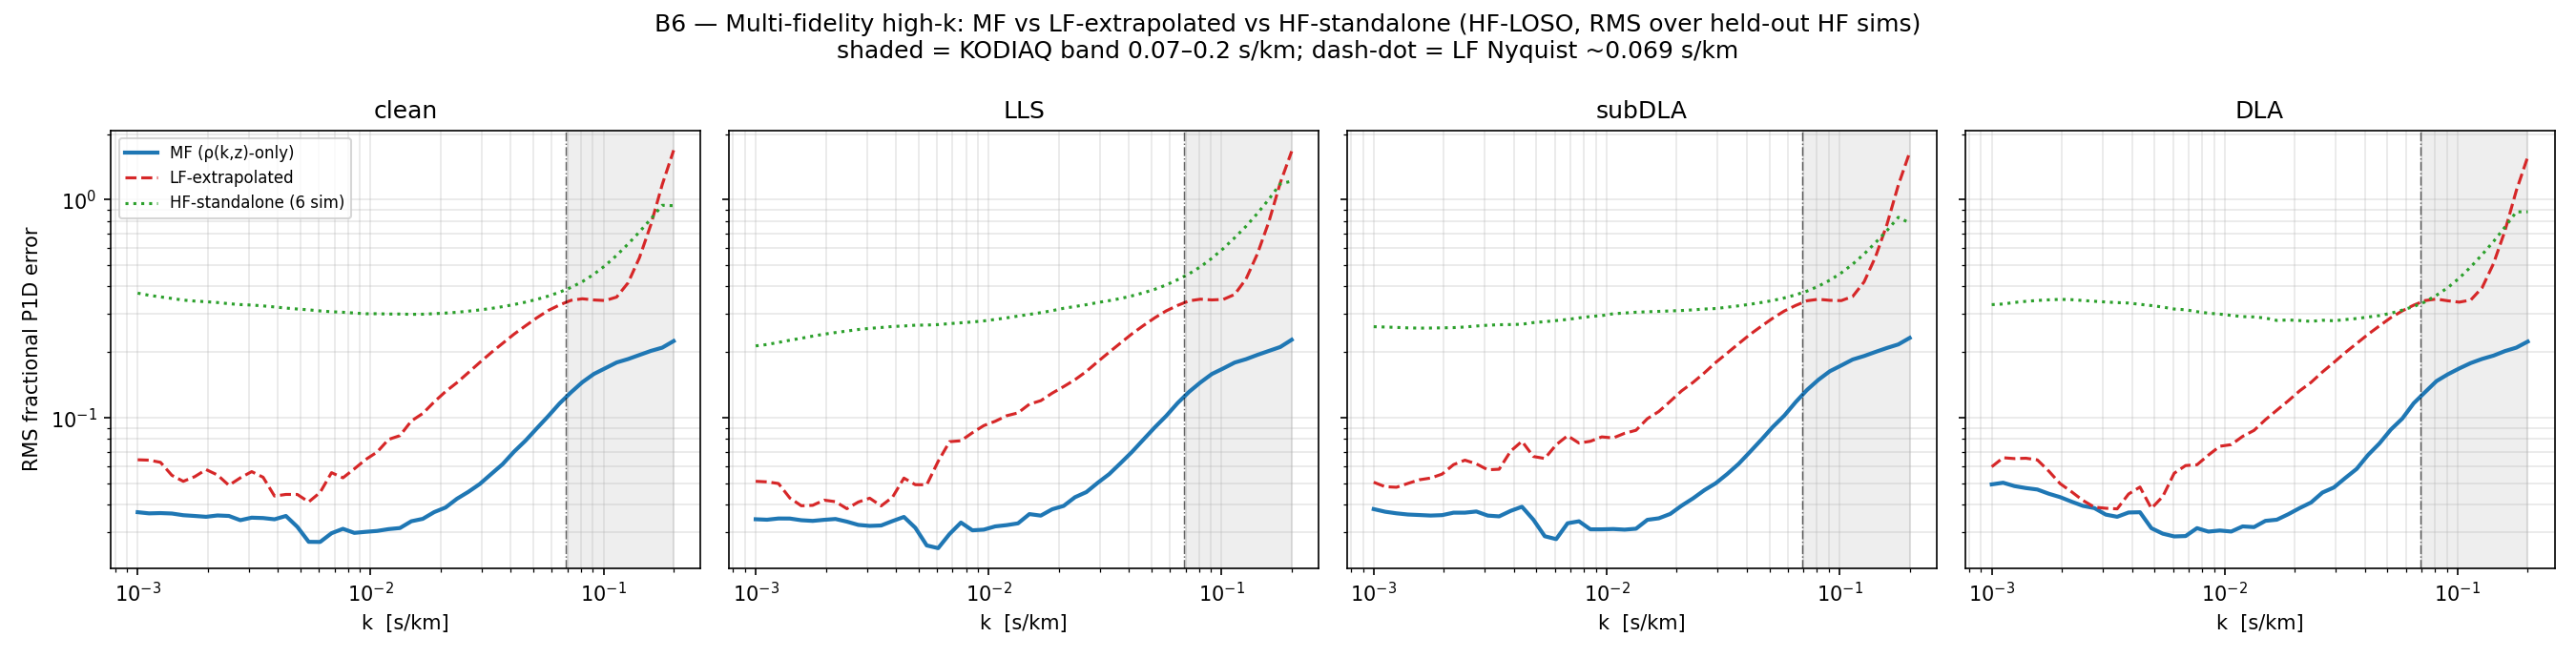

In [8]:
try:
    p, mfsum = W.figB6_mf_high_k(d)
    if p is None:
        print('B6 skipped:', mfsum)
    else:
        print('B6 KODIAQ-band RMS frac err per class:')
        for nm, v in mfsum.items():
            print(f"  {nm:7s} MF={v['mf_kodiaq']:.3f}  "
                  f"LF-extrap={v['lf_kodiaq']:.3f}  HF-standalone={v['hf_kodiaq']:.3f}")
        display(Image(filename=str(p)))
except Exception as e:
    print('B6 unavailable (MF setup failed); continuing:', repr(e))

## HEAD A — dN/dX + CDDF

We build the Head-A held-out stacks over all loaded folds once, then render its
figures. (`_head_a_stacks` evaluates Head A on every fold's held-out rows.)

In [9]:
S = W._head_a_stacks(models, norms, splits, d)
print('Head-A held-out stack built:',
      {k: np.asarray(v).shape for k, v in S.items()
       if k in ('dndx_fe', 'fnhi_fe', 'wc_emu', 'ptp_fe')})

Head-A held-out stack built: {'dndx_fe': (18224, 3), 'fnhi_fe': (18224, 30), 'wc_emu': (18224, 4), 'ptp_fe': (18224, 172)}


### A1 — dN/dX fractional accuracy vs z (per class)

**What:** median & p95 `|frac err|` of the predicted line-density `dN/dX` vs z,
for LLS / subDLA / DLA. **How to read:** both curves should sit under the 2.5%
target (red dotted); DLA is noisiest (rarest). **Good:** median well under 2.5%
across z. **Bad:** a class/z rising above target.

A1 dN/dX median |frac err| per class: {'LLS': 1.571, 'subDLA': 1.648, 'DLA': 1.25}


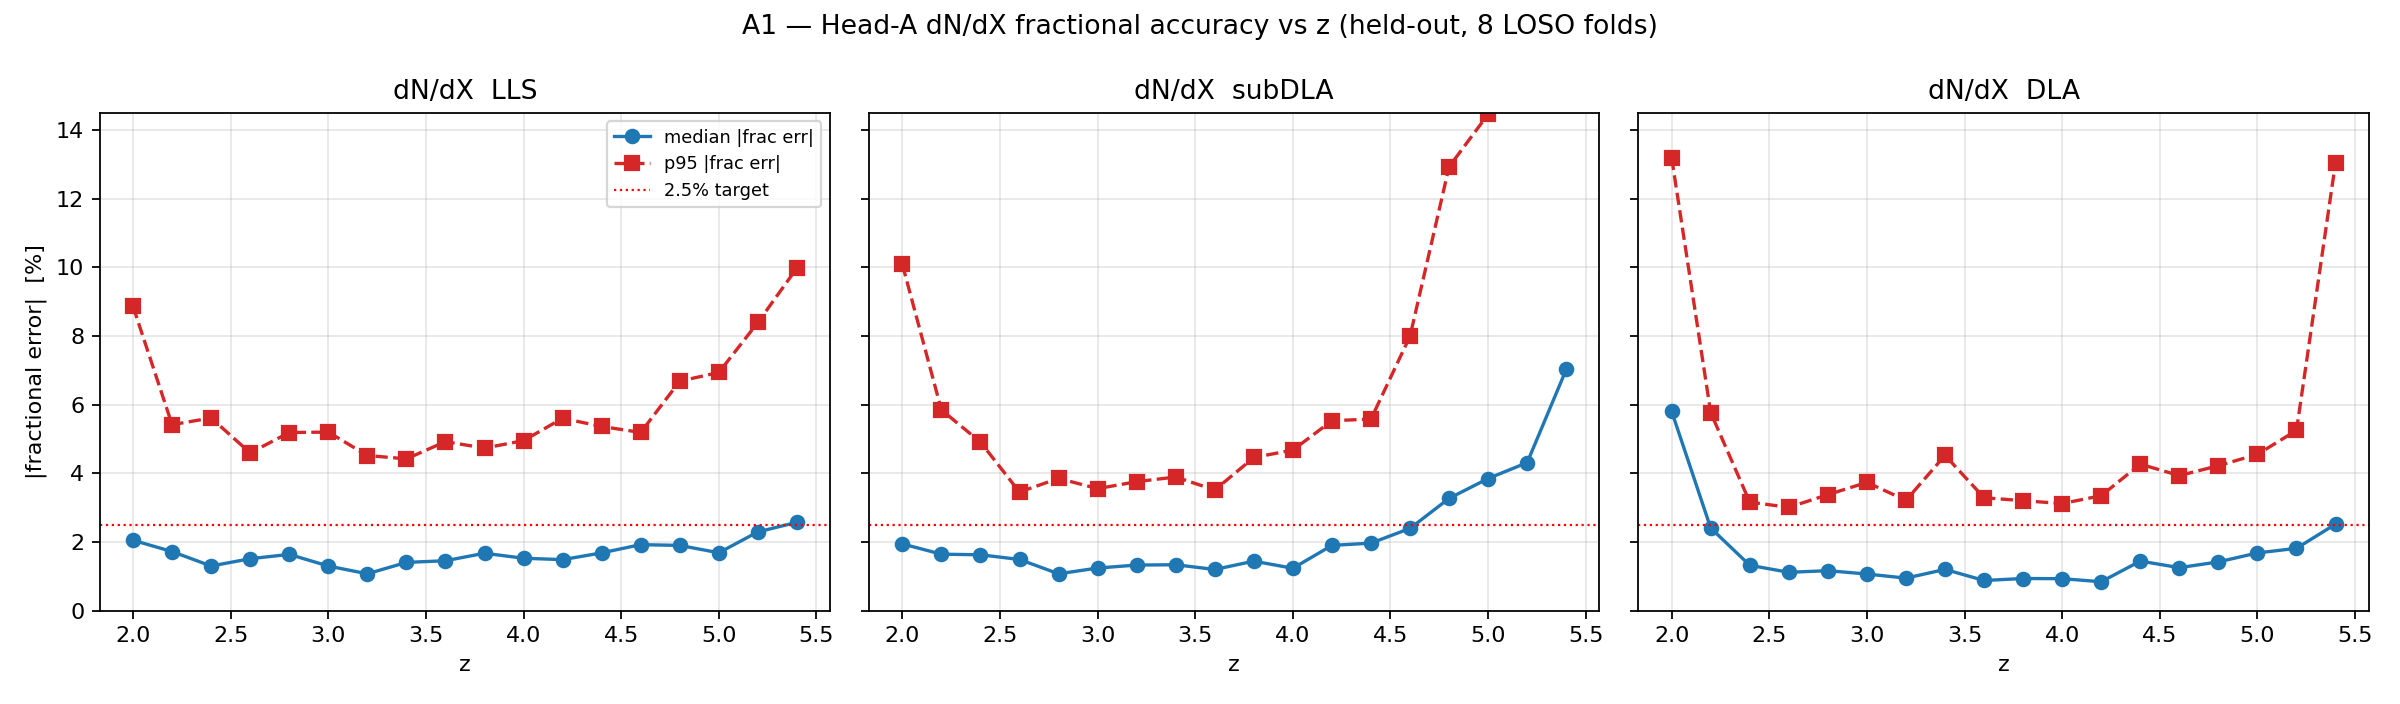

In [10]:
p, a1 = W.figA1_dndx_pred_vs_true(S, z_levels)
print('A1 dN/dX median |frac err| per class:',
      {k: round(v['median_pct'], 3) for k, v in a1.items()})
display(Image(filename=str(p)))

### A2 — CDDF (f_NHI) accuracy vs logN_HI

**What:** median & p95 `|frac err|` of the CDDF per N_HI bin; vertical lines mark
the class boundaries (17.2 / 19.0 / 20.3), the shaded band is the shot-noise tail
(logN_HI ≥ 21.5), and the grey curve (right axis) is the valid-row fraction.
**How to read:** error should be low and flat across the populated range and is
*expected* to blow up in the shot-noise tail (few absorbers). **Good:** sub-few-%
below 21.5. **Bad:** large error *below* 21.5 where statistics are ample.

A2 CDDF median |frac err| = 2.295%  (p95 34.088%)


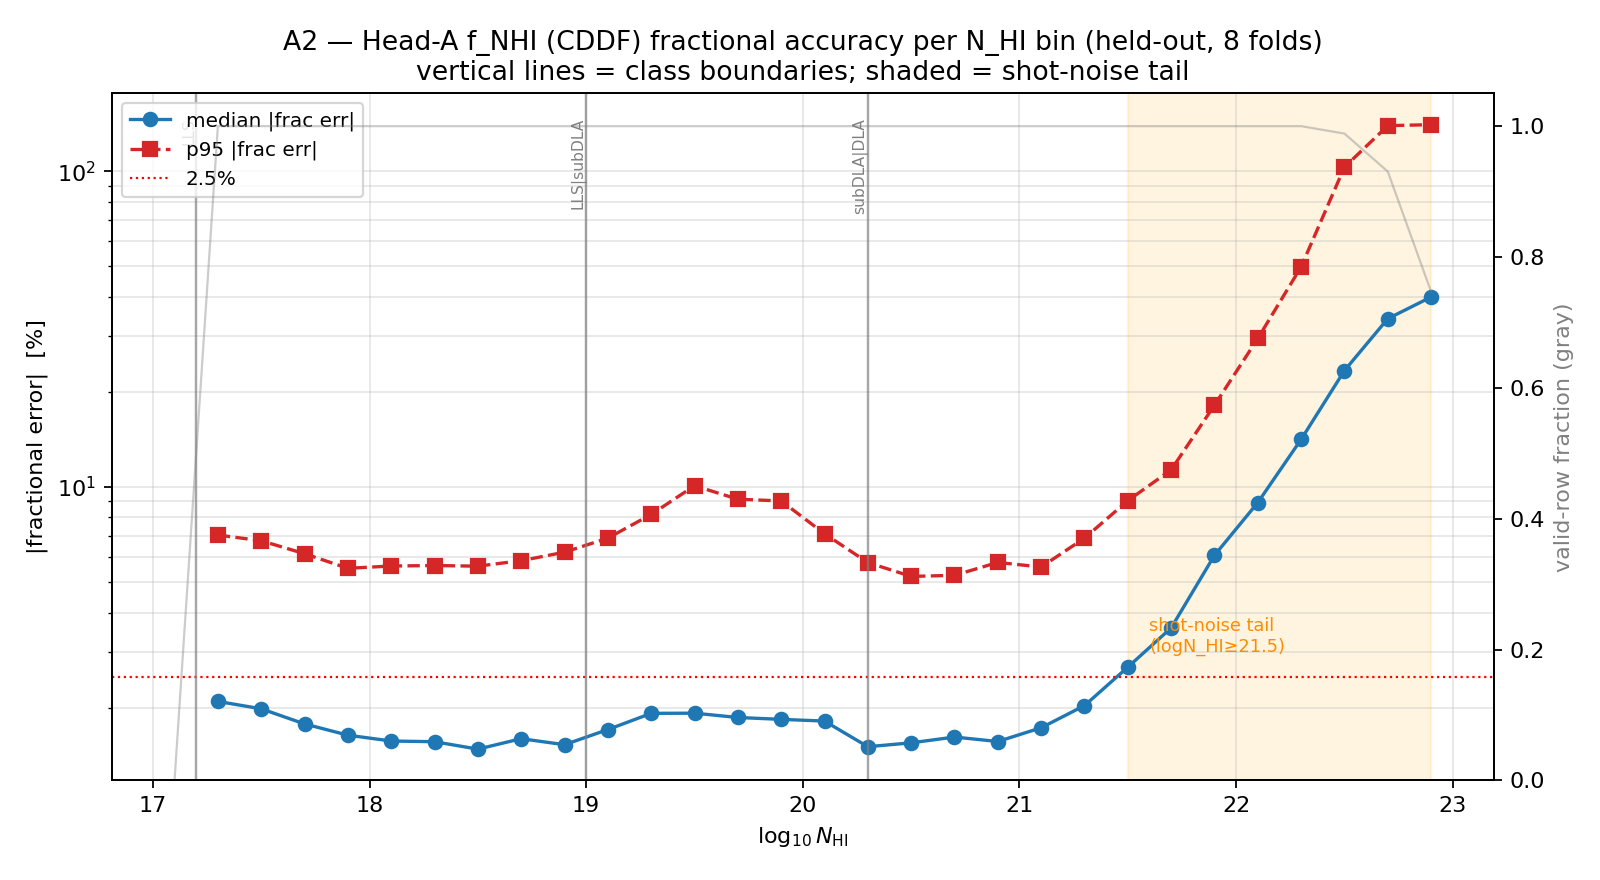

In [11]:
p, a2 = W.figA2_cddf_pred_vs_true(S)
print(f"A2 CDDF median |frac err| = {a2['median_pct']:.3f}%  (p95 {a2['p95_pct']:.3f}%)")
display(Image(filename=str(p)))

### A3 — w_c → P_tier_p coupling

**What:** *left* — the class weights `w_c` from emulated vs true dN/dX
(round-trip); *middle* — the `|w_c(emu)−w_c(true)|` error distribution; *right*
— the resulting fractional error on the **structural total** `P_tier_p = Σ_c
w_c·P_filt`. **How to read:** the scatter should hug `y=x`; the P_tier_p error
should sit inside the ±2.5% target band. **Good:** tight w_c round-trip, P_tier_p
p95 ≲ 2.5%. **Bad:** biased w_c that propagates into a P_tier_p offset.

A3 P_tier_p frac err: median 0.037%  p95 0.222%


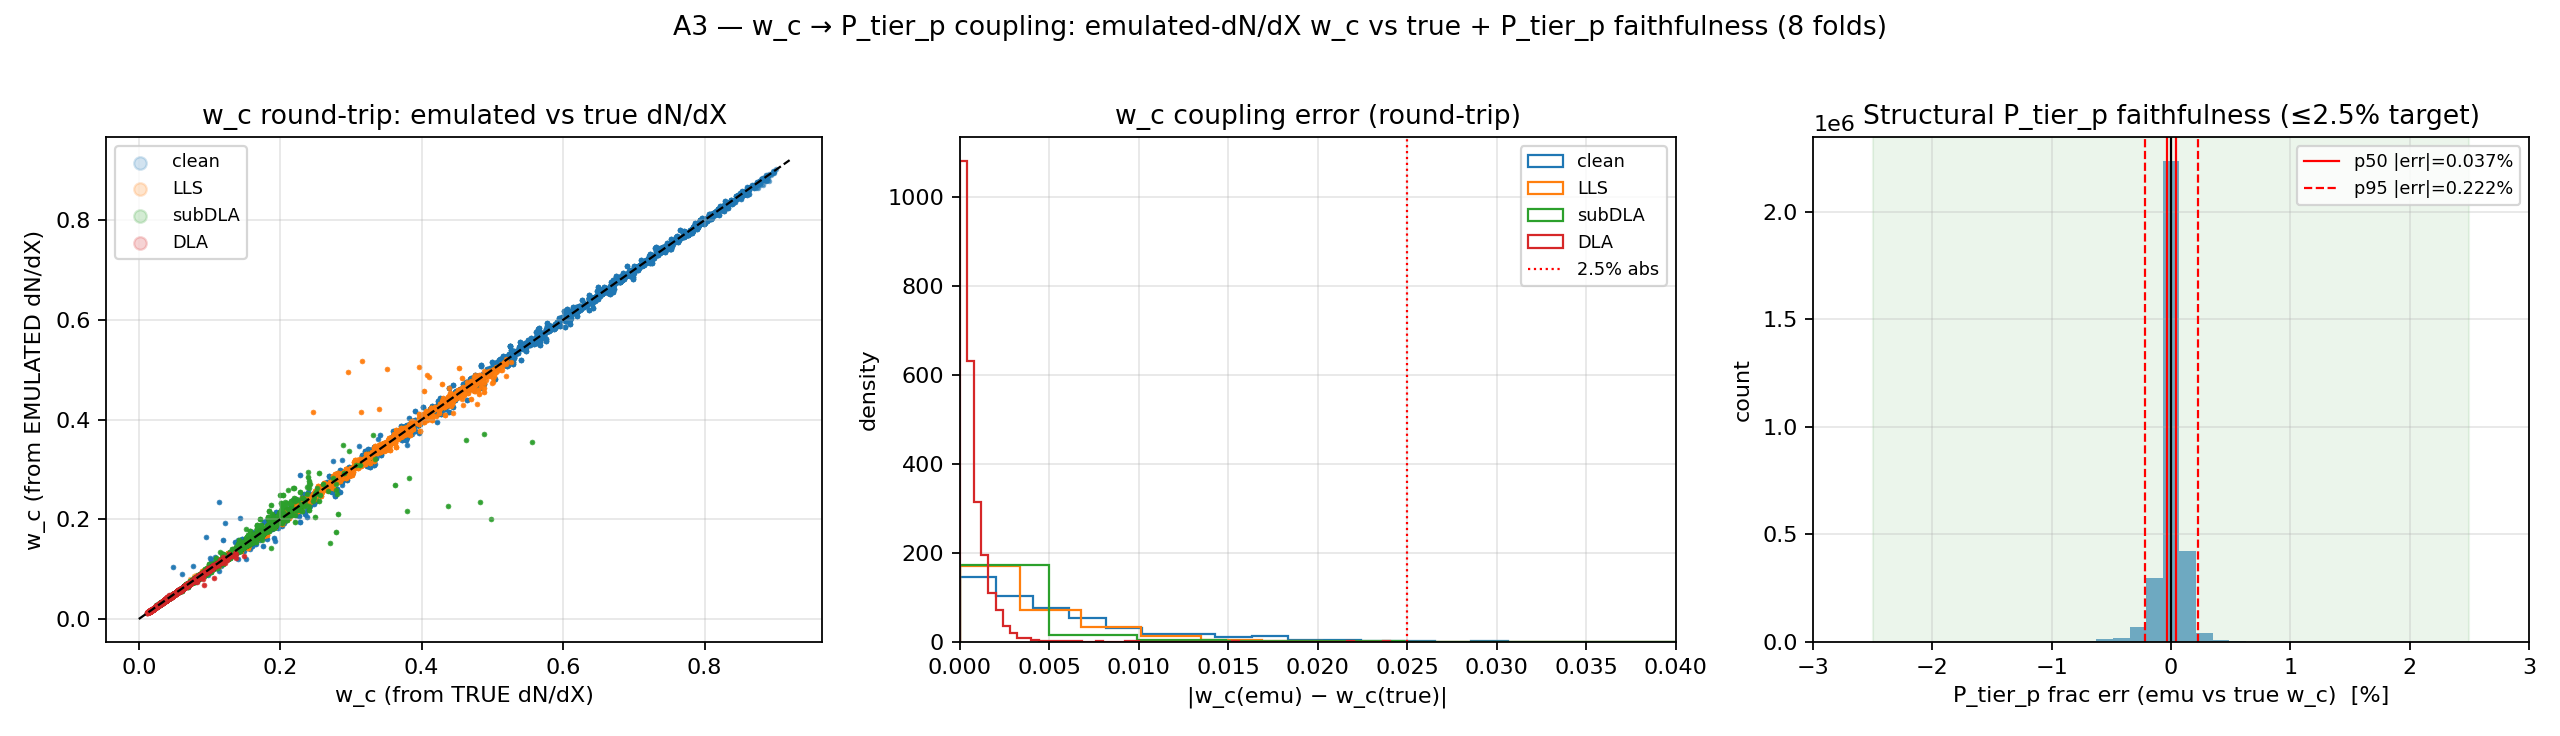

In [12]:
p, a3 = W.figA3_wc_ptierp_coupling(S)
print(f"A3 P_tier_p frac err: median {a3['ptierp_median_pct']:.3f}%  "
      f"p95 {a3['ptierp_p95_pct']:.3f}%")
display(Image(filename=str(p)))

### A4 — Head-A dN/dX error heatmap (class × z × fold)

**What:** median `|frac err|` of dN/dX as a heatmap over (fold, z) for each HCD
class. **How to read:** uniform color = well-balanced across folds and z; a hot
row flags a weak fold, a hot column a weak z. **Good:** even, cool map. **Bad:** a
persistent hot stripe.

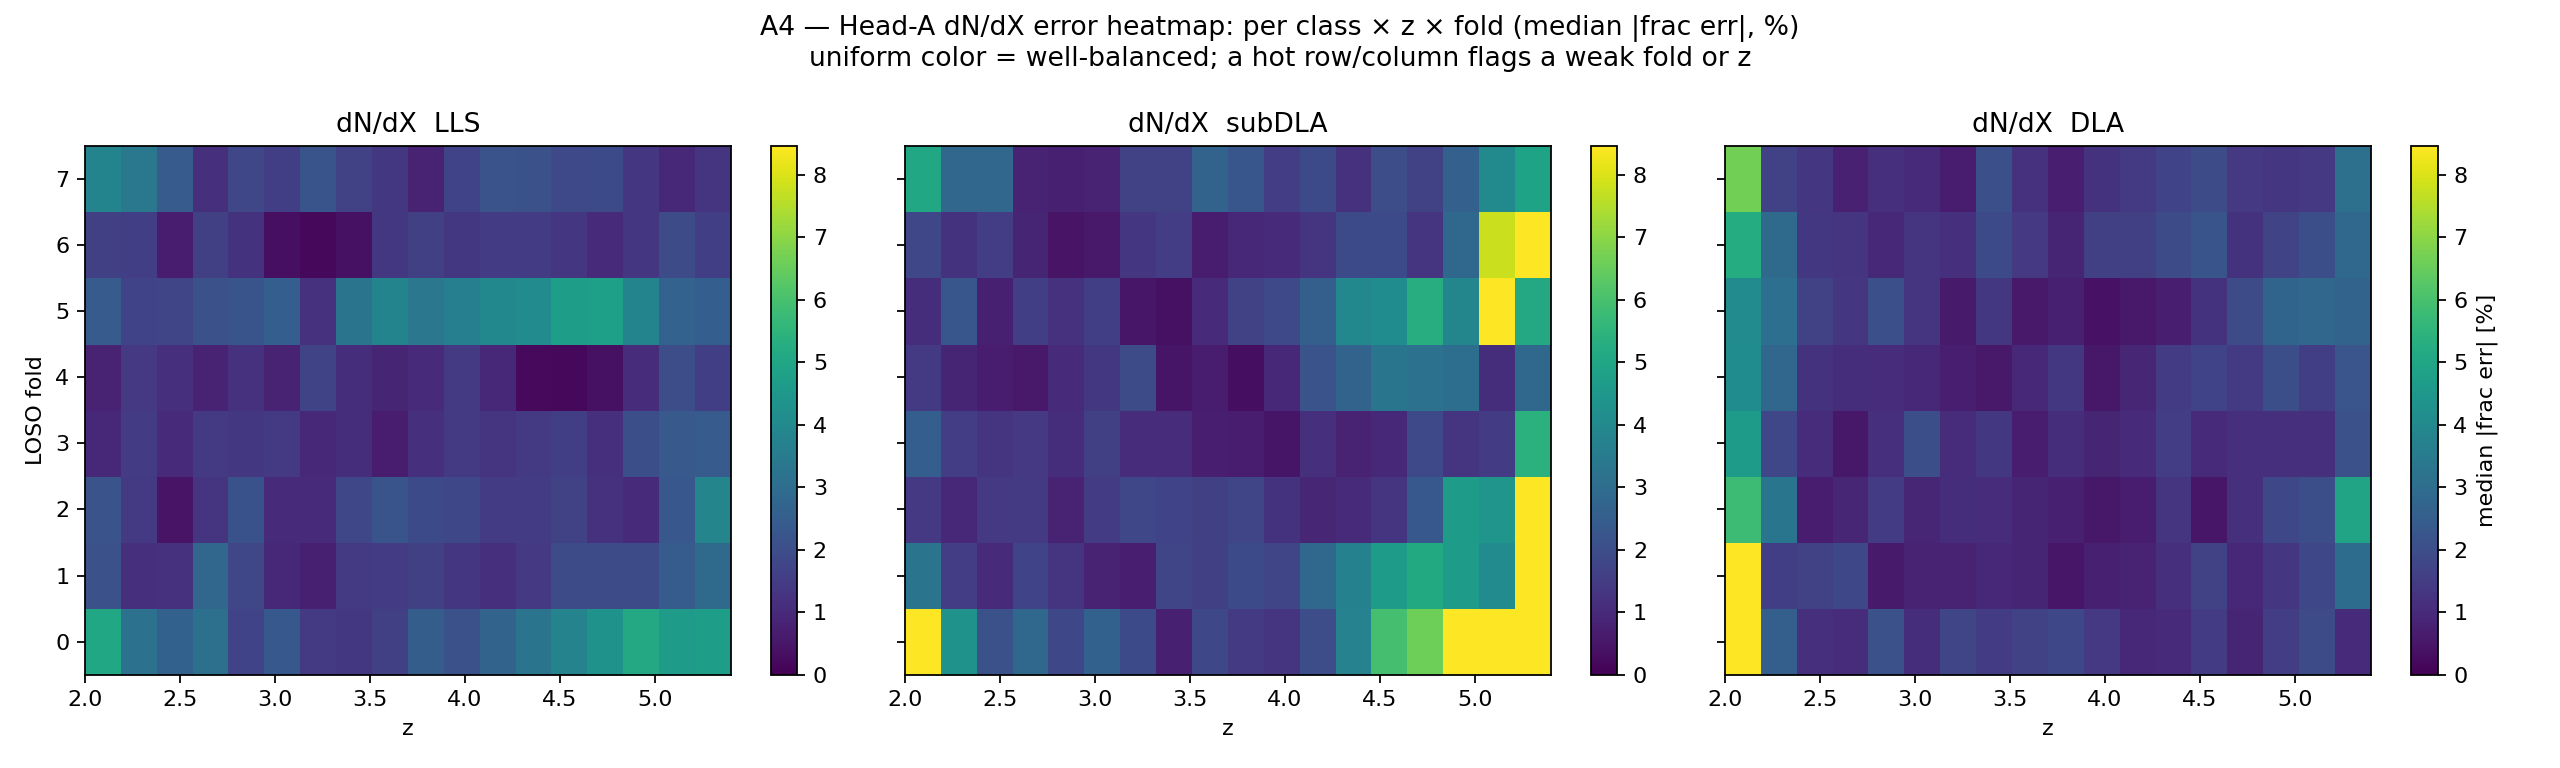

In [13]:
p = W.figA4_head_a_error_heatmap(S, z_levels)
display(Image(filename=str(p)))

### A5 — dN/dX → α_c prior-center sanity

**What:** the emulated `w_c` (which sets the α_c prior center) vs the cache's
empirical CDDF-integral `w_c`. **How to read:** the scatter should hug `y=x` and
the deviation histogram should peak well inside the 2.5% mark. **Good:** the
emulated prior center matches the cache CDDF. **Bad:** a systematic offset
(the prior would be mis-centered).

A5 |w_c(emu)−w_c(cache)| median per class: {'clean': 0.0042, 'LLS': 0.003, 'subDLA': 0.0013, 'DLA': 0.0005}


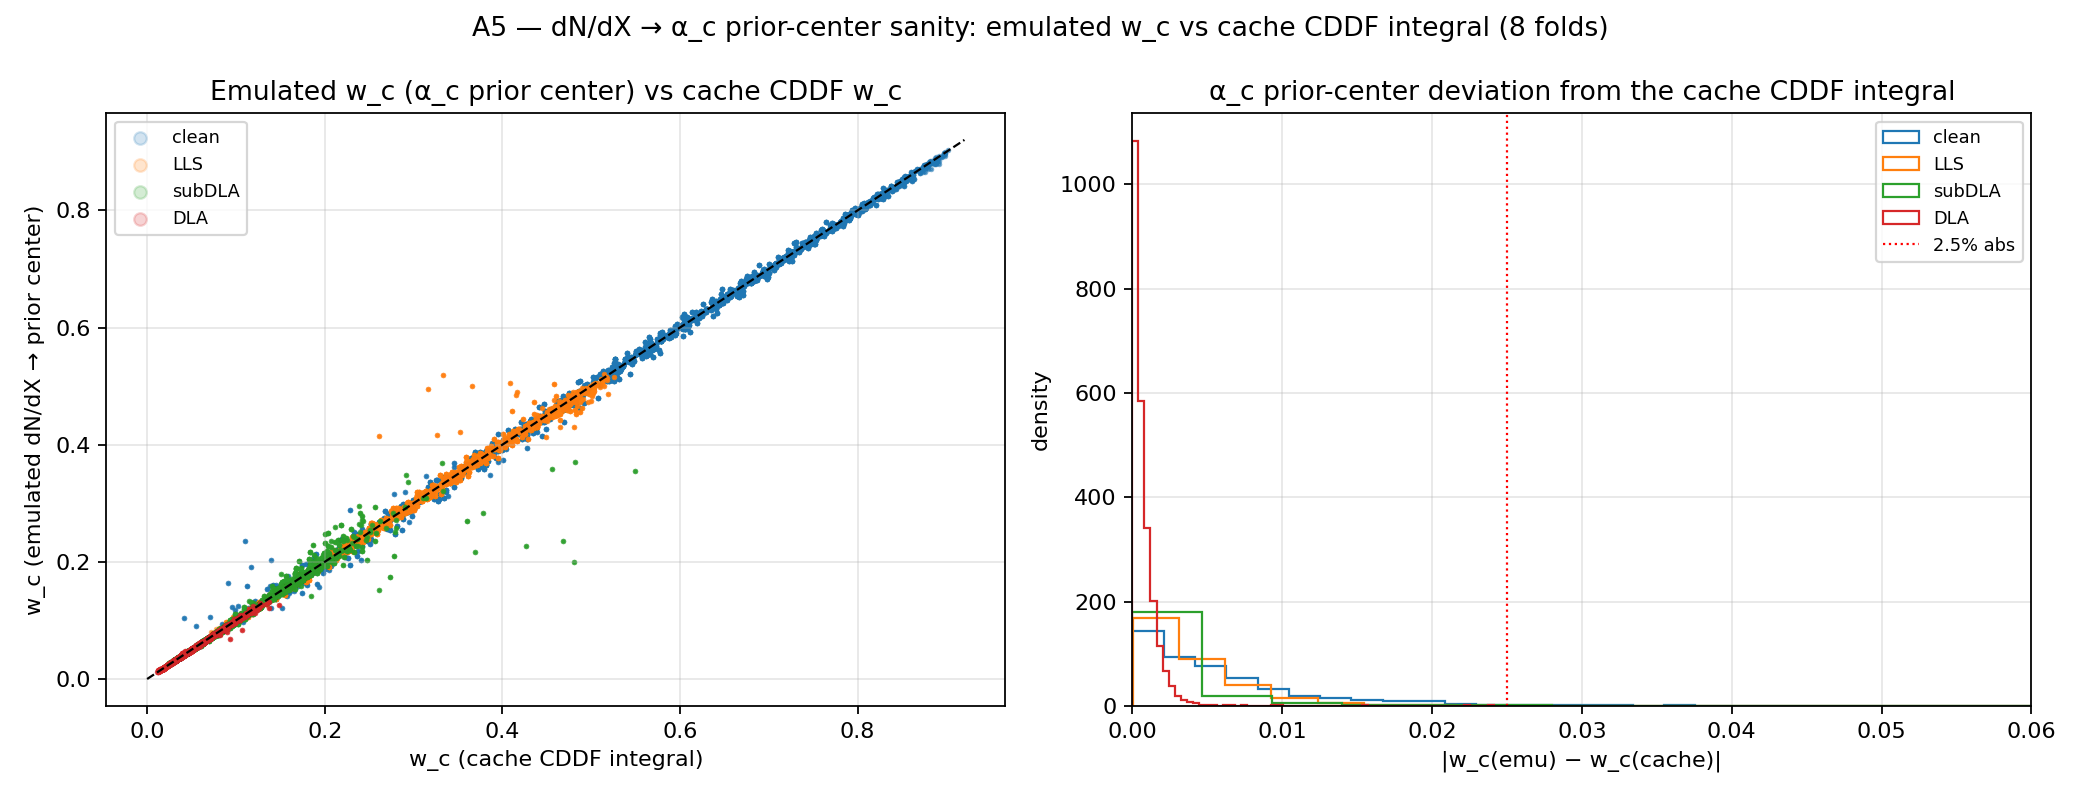

In [14]:
p, a5 = W.figA5_alpha_prior_sanity(S)
print('A5 |w_c(emu)−w_c(cache)| median per class:',
      {k: round(v['median'], 4) for k, v in a5.items()})
display(Image(filename=str(p)))

### B7 — Δ_c HCD class templates

**What:** the deployed per-HCD-class `Δ_c` template (HeadB delta output) vs k at
several held-out z slices (symlog-y). **How to read:** `Δ_c` is the shape that
re-weights the structural `P_tier_p`; the low-k sign-flip is physical. **Good:**
smooth, z-ordered templates. **Bad:** noisy, non-monotone-in-z templates.

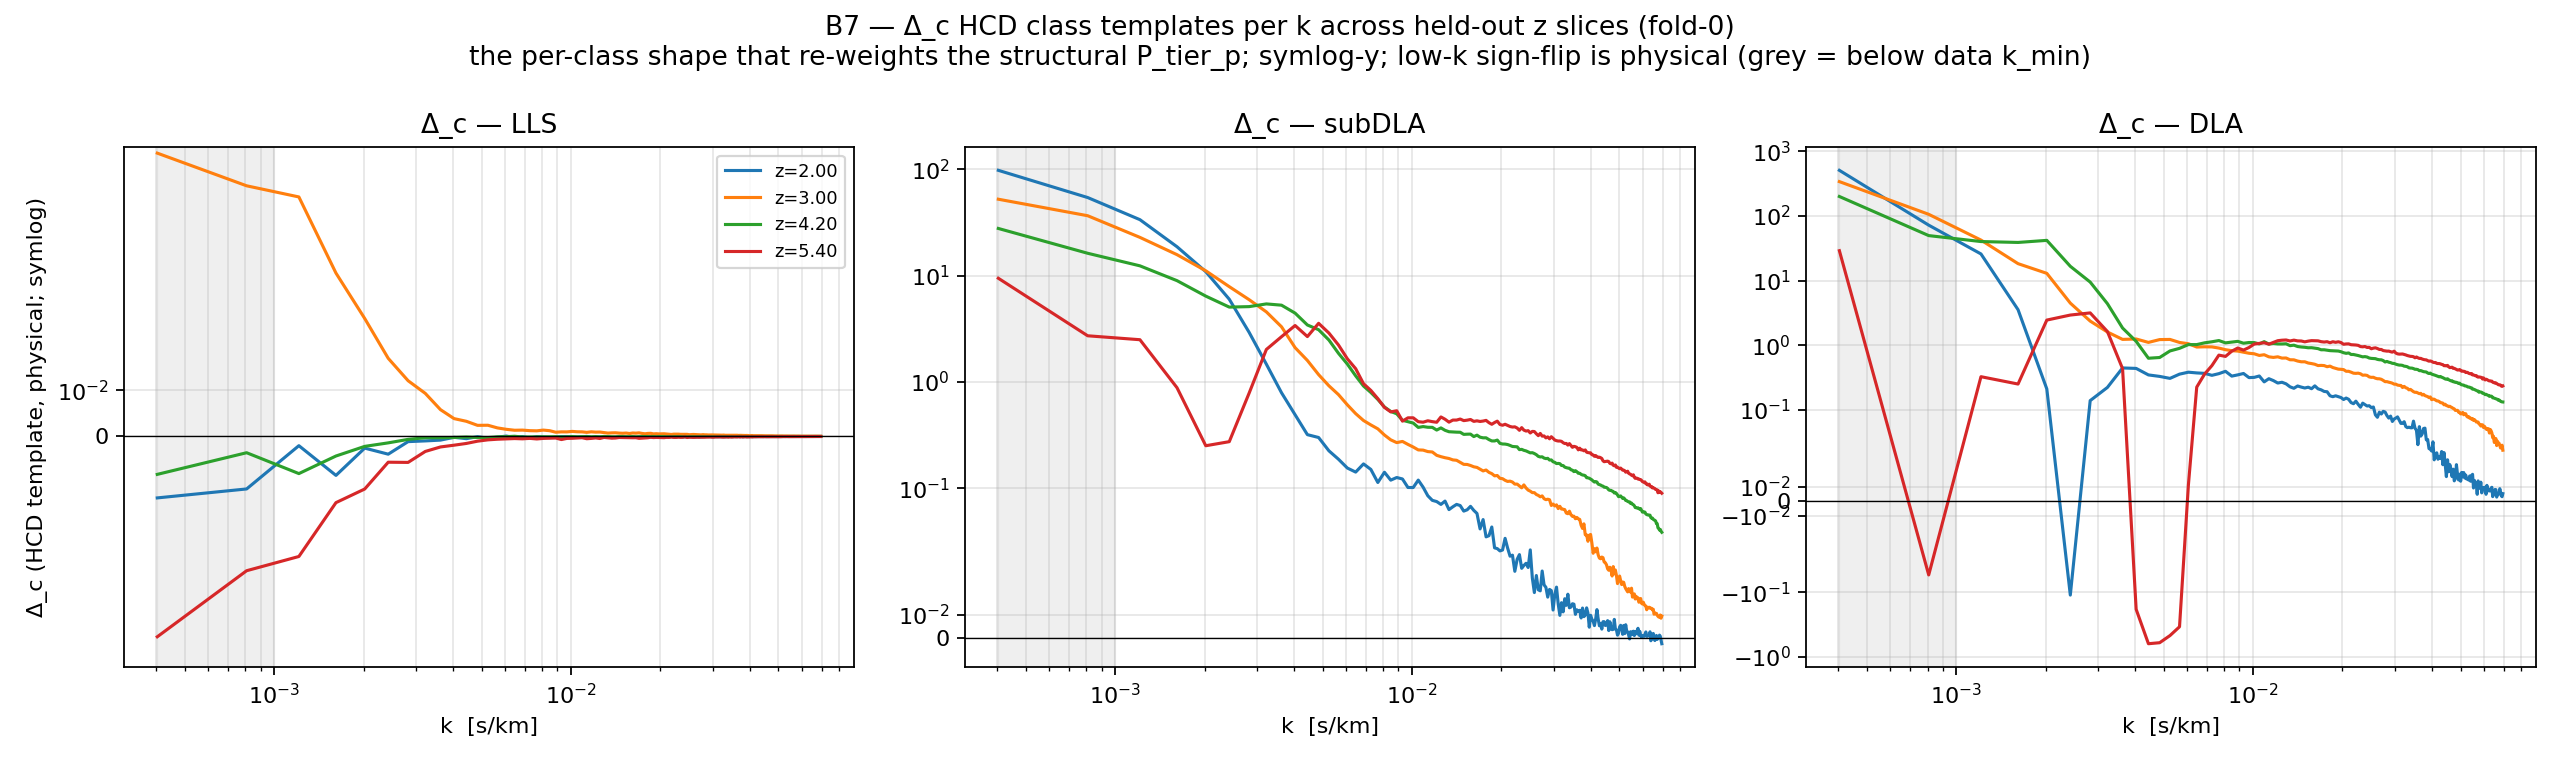

In [15]:
p = W.figB7_delta_c_templates(m0, n0, s0, d, kf)
display(Image(filename=str(p)))

## Summary

All figures above are written to
`figures/analysis/06_performance_walkthrough/` (and rendered inline) by the same
functions the production walkthrough script uses. To regenerate the entire set
outside the notebook (incl. the headline-numbers JSON):

```bash
PYTHONNOUSERSITE=1 PYTHONPATH="$PWD" \   # run from the repo root
  /home/mfho/.conda/envs/emu-jax/bin/python3 scripts/plot_performance_walkthrough.py
#   add --no-mf to skip B6 if the HR cache / res_corr table is unavailable
```